In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Load and understand the Dataset


In [189]:
ds = pd.read_csv('boston_housing_clean.xlsx - Sheet1.csv')
ds


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [190]:
ds.shape

(506, 14)

In [191]:
ds.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [192]:
ds.tail()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [193]:
ds.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [194]:
ds.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.593761,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.596783,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.647423,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [195]:
ds.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [196]:
ds.isnull().sum().sum()

np.int64(0)

# Exploratory Data Analysis

In [197]:
# for col in ds.columns:
#     plt.figure(figsize=(6,4))
#     sns.boxplot(x=ds[col])

<Axes: xlabel='MEDV', ylabel='Count'>

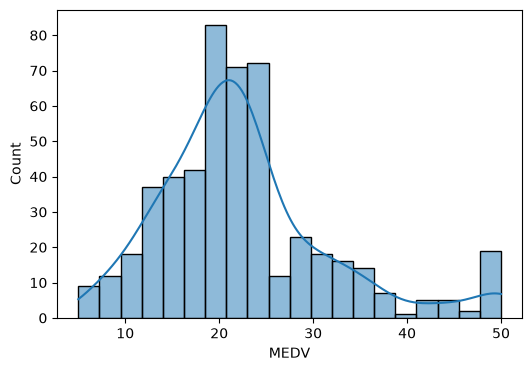

In [198]:
plt.figure(figsize=(6,4))
sns.histplot(ds['MEDV'],kde=True,bins=20)

In [199]:
# plt.figure(figsize=(15,10))
# sns.heatmap(ds.corr(numeric_only=True),annot=True)

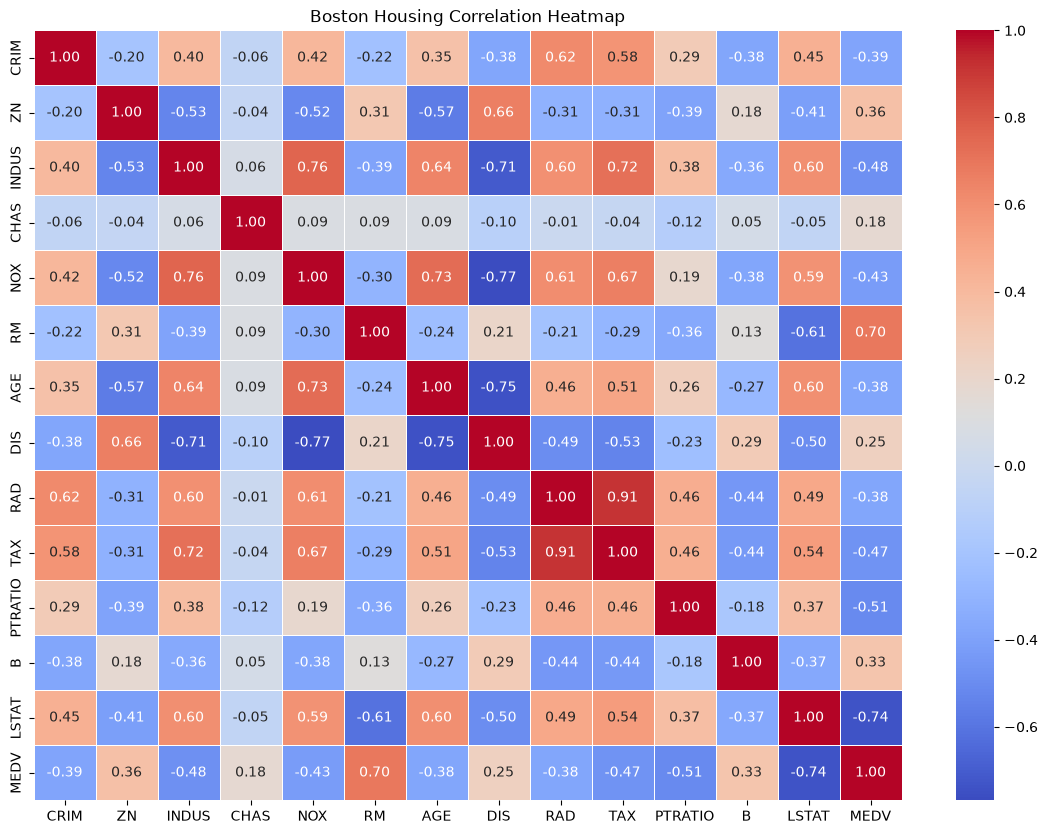

In [200]:
corr = ds.corr(numeric_only=True)


plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Boston Housing Correlation Heatmap")
plt.show()

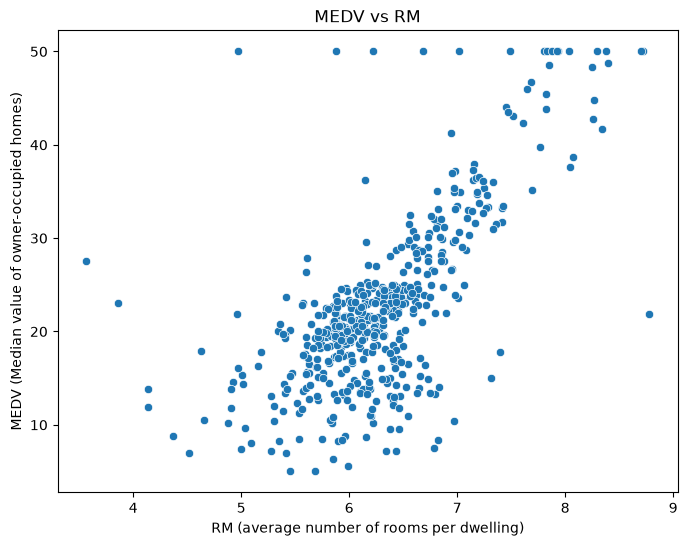

In [201]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=ds, x='RM', y='MEDV')
plt.title('MEDV vs RM')
plt.xlabel('RM (average number of rooms per dwelling)')
plt.ylabel('MEDV (Median value of owner-occupied homes)')
plt.show()

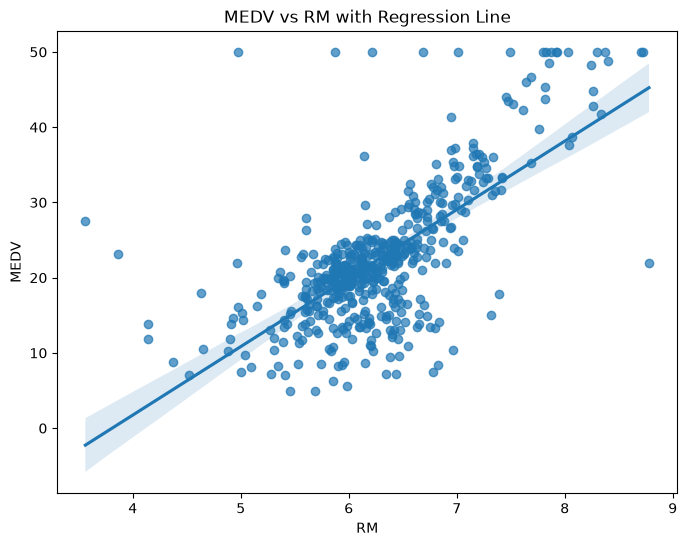

In [202]:
plt.figure(figsize=(8, 6))
sns.regplot(data=ds, x='RM', y='MEDV', scatter_kws={'alpha':0.7})
plt.title('MEDV vs RM with Regression Line')
plt.xlabel('RM')
plt.ylabel('MEDV')
plt.show()

In [203]:
x=ds[['CRIM','ZN','INDUS','NOX','RM','AGE','DIS','TAX','PTRATIO','B','LSTAT']]
y=ds['MEDV']

In [204]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [205]:
model = LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](11,)","[-0.08, 0.02, 0. ,...,-0.84, 0.01,-0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,23.53
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(11)


In [206]:
print("Coefficients:")

for feature, coefficient in zip(x.columns, model.coef_):
    print(feature, "=", round(coefficient, 3))

print("Intercept =", round(model.intercept_, 3))

Coefficients:
CRIM = -0.085
ZN = 0.023
INDUS = 0.003
NOX = -14.271
RM = 4.819
AGE = -0.009
DIS = -1.445
TAX = 0.001
PTRATIO = -0.839
B = 0.012
LSTAT = -0.514
Intercept = 23.532


In [207]:
y_pred = model.predict(x_test)

In [208]:
print("\nActual vs Predicted")

for actual, predicted in zip(y_test, y_pred):
    print(
        f"Actual: {actual:.2f} | Predicted: {predicted:.2f}"
    )


Actual vs Predicted
Actual: 23.60 | Predicted: 29.11
Actual: 32.40 | Predicted: 32.95
Actual: 13.60 | Predicted: 19.29
Actual: 22.80 | Predicted: 25.23
Actual: 16.10 | Predicted: 18.45
Actual: 20.00 | Predicted: 24.09
Actual: 17.80 | Predicted: 17.91
Actual: 14.00 | Predicted: 16.12
Actual: 19.60 | Predicted: 22.13
Actual: 16.80 | Predicted: 21.59
Actual: 21.50 | Predicted: 21.49
Actual: 18.90 | Predicted: 18.43
Actual: 7.00 | Predicted: -6.11
Actual: 21.20 | Predicted: 22.62
Actual: 18.50 | Predicted: 19.05
Actual: 29.80 | Predicted: 25.92
Actual: 18.80 | Predicted: 19.63
Actual: 10.20 | Predicted: 5.06
Actual: 50.00 | Predicted: 40.29
Actual: 14.10 | Predicted: 17.35
Actual: 25.20 | Predicted: 26.94
Actual: 29.10 | Predicted: 29.65
Actual: 12.70 | Predicted: 11.77
Actual: 22.40 | Predicted: 25.38
Actual: 14.20 | Predicted: 17.50
Actual: 13.80 | Predicted: 14.88
Actual: 20.30 | Predicted: 23.56
Actual: 14.90 | Predicted: 14.56
Actual: 21.70 | Predicted: 19.42
Actual: 18.30 | Predicte

In [209]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
adjusted_r2 = 1 - (1 - r2) * (len(y_test) - 1) / (len(y_test) - x_test.shape[1] - 1)

In [210]:
print("\nPerformance Metrics")
print("--------------------")

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)
print("Adjusted R²:", adjusted_r2)


Performance Metrics
--------------------
MAE : 3.4120062321821094
MSE : 27.090697869359328
RMSE: 5.204872512306073
R²  : 0.630583658692019
Adjusted R²: 0.5854327725321546


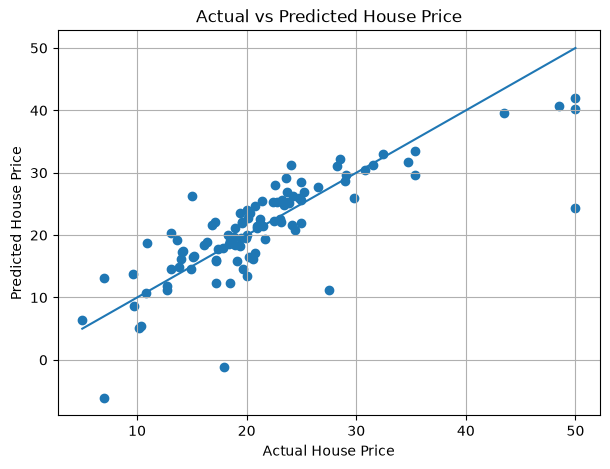

In [211]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Price")
plt.grid(True)

plt.show()

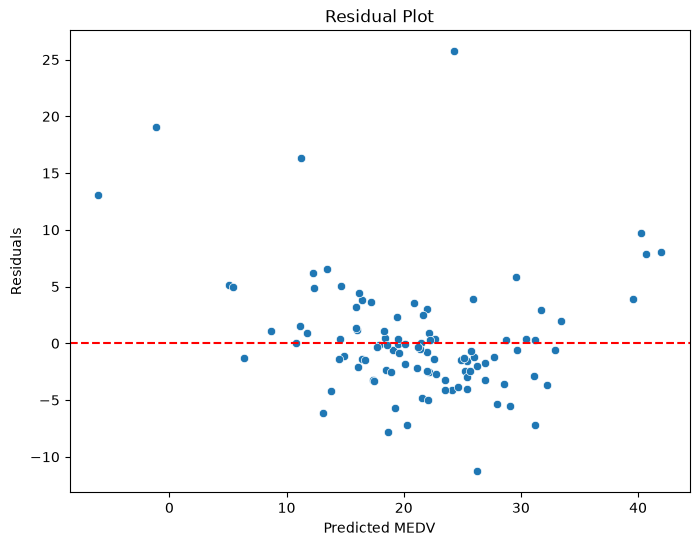

In [212]:

# y_pred is the predicted MEDV values from the model
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted MEDV')
plt.ylabel('Residuals')
plt.show()

### Strong positive attribute Coefficient:
RM = 4.82

### Strong Negative  attribute coefficient:
NOX : -14.27 <br>
DIS = -1.44

### Interpretation of R² = 0.63

The regression model explains 63% of the variation in house prices (MEDV).
The remaining 37% of the variation is not explained by the predictors in the model.
